In [61]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

try:
    from lifelines import KaplanMeierFitter, CoxPHFitter
    from lifelines.utils import concordance_index
except ModuleNotFoundError:
    print("Installing lifelines...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lifelines", "-q"])
    from lifelines import KaplanMeierFitter, CoxPHFitter
    from lifelines.utils import concordance_index

In [62]:

RANDOM_STATE = 42

# Turn sampling on only if runtime becomes annoying on your machine.
USE_SAMPLE = False
SAMPLE_SIZE = 250_000

SIX_HORIZON = 6
SHORT_HORIZON = 12
EIGHTEEN_HORIZON = 18
LONG_HORIZON = 24

TRAIN_END = "2014-12-31"
VALID_START, VALID_END = "2015-01-01", "2015-12-31"
TEST_START, TEST_END = "2016-01-01", "2019-12-31"

DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
OUTPUT_DIR = DATA_DIR / "simplification_PD"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: /Users/pattonpatton/Desktop/RiskProject/Risk_Management_Project/Time Based/data/simplification_PD


## 2. Find and load the LendingClub file

In [63]:

def find_accepted_file():
    candidates = [
        Path("data/raw/lendingclub/accepted_2007_to_2018Q4.csv.gz"),
        Path("data/raw/accepted_2007_to_2018Q4.csv.gz"),
        Path("accepted_2007_to_2018Q4.csv.gz"),
        Path("/mnt/data/accepted_2007_to_2018Q4.csv.gz"),
        Path("/mnt/data/data/raw/lendingclub/accepted_2007_to_2018Q4.csv.gz"),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "Could not find accepted_2007_to_2018Q4.csv.gz. Put it in data/raw/lendingclub/ "
        "or edit find_accepted_file()."
    )

accepted_path = find_accepted_file()
print("Using raw file:", accepted_path)

Using raw file: data/raw/lendingclub/accepted_2007_to_2018Q4.csv.gz


In [64]:

key_columns = [
    "id",
    "loan_status",
    "issue_d",
    "term",
    "grade",
    "int_rate",
    "loan_amnt",
    "installment",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "fico_range_low",
    "fico_range_high",
    "earliest_cr_line",
    "last_pymnt_d",
    "last_credit_pull_d",
]

df_raw = pd.read_csv(
    accepted_path,
    usecols=lambda c: c in key_columns,
    low_memory=False,
    compression="gzip",
)

if USE_SAMPLE:
    df_raw = df_raw.sample(min(SAMPLE_SIZE, len(df_raw)), random_state=RANDOM_STATE).copy()

print("Raw shape:", df_raw.shape)
display(df_raw.head(3))

Raw shape: (2260701, 28)


,id,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,...,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,last_pymnt_d,last_credit_pull_d,mort_acc,pub_rec_bankruptcies
0,68407277,3600.0,36 months,13.99,123.03,C,10+ years,MORTGAGE,55000.0,Not Verified,...,1.0,7.0,0.0,2765.0,29.7,13.0,Jan-2019,Mar-2019,1.0,0.0
1,68355089,24700.0,36 months,11.99,820.28,C,10+ years,MORTGAGE,65000.0,Not Verified,...,4.0,22.0,0.0,21470.0,19.2,38.0,Jun-2016,Mar-2019,4.0,0.0
2,68341763,20000.0,60 months,10.78,432.66,B,10+ years,MORTGAGE,63000.0,Not Verified,...,0.0,6.0,0.0,7869.0,56.2,18.0,Jun-2017,Mar-2019,5.0,0.0


## 3. Clean the loan-level data

In [65]:

df = df_raw.copy()

for c in ["issue_d", "earliest_cr_line", "last_pymnt_d", "last_credit_pull_d"]:
    df[c] = pd.to_datetime(df[c], format="%b-%Y", errors="coerce")

status = df["loan_status"].fillna("").astype(str)

# Keep the default definition simple and consistent.
default_mask = status.str.contains("Charged Off|Default", case=False, regex=True)
payoff_mask = status.str.contains("Fully Paid", case=False, regex=False) & (~default_mask)

df["default_event"] = default_mask.astype(int)
df["payoff_event"] = payoff_mask.astype(int)
df["event_type"] = np.select(
    [df["default_event"] == 1, df["payoff_event"] == 1],
    [1, 2],
    default=0,
)

df["term_num"] = (
    df["term"].astype(str).str.extract(r"(\d+)", expand=False).astype(float)
)

# Strip percentage signs where needed.
df["int_rate"] = (
    df["int_rate"].astype(str).str.replace("%", "", regex=False)
)
df["int_rate"] = pd.to_numeric(df["int_rate"], errors="coerce")

df["fico_avg"] = (df["fico_range_low"] + df["fico_range_high"]) / 2
df["credit_history_years"] = (
    (df["issue_d"] - df["earliest_cr_line"]).dt.days / 365.25
)

df["end_date"] = df["last_pymnt_d"]
missing_end = df["end_date"].isna()
df.loc[missing_end, "end_date"] = df.loc[missing_end, "last_credit_pull_d"]

def month_diff(start, end):
    return (end.dt.year - start.dt.year) * 12 + (end.dt.month - start.dt.month)

df = df[df["issue_d"].notna()].copy()
df = df[df["end_date"].notna()].copy()

df["duration_months"] = month_diff(df["issue_d"], df["end_date"]).clip(lower=1)

numeric_cols = [
    "int_rate",
    "loan_amnt",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "fico_avg",
    "credit_history_years",
    "term_num",
]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df_model = df[df["issue_d"] <= pd.Timestamp(TEST_END)].copy()

print("Clean modeling shape:", df_model.shape)
print("Default share:", round(df_model["default_event"].mean(), 4))
print("Payoff share :", round(df_model["payoff_event"].mean(), 4))
display(df_model[["id", "issue_d", "loan_status", "default_event", "payoff_event", "duration_months"]].head())

Clean modeling shape: (2260668, 36)
Default share: 0.1192
Payoff share : 0.4772


,id,issue_d,loan_status,default_event,payoff_event,duration_months
0,68407277,2015-12-01,Fully Paid,0,1,37
1,68355089,2015-12-01,Fully Paid,0,1,6
2,68341763,2015-12-01,Fully Paid,0,1,18
3,66310712,2015-12-01,Current,0,0,38
4,68476807,2015-12-01,Fully Paid,0,1,7


In [66]:

train_loans = df_model[df_model["issue_d"] <= pd.Timestamp(TRAIN_END)].copy()
valid_loans = df_model[
    (df_model["issue_d"] >= pd.Timestamp(VALID_START)) &
    (df_model["issue_d"] <= pd.Timestamp(VALID_END))
].copy()
test_loans = df_model[
    (df_model["issue_d"] >= pd.Timestamp(TEST_START)) &
    (df_model["issue_d"] <= pd.Timestamp(TEST_END))
].copy()

split_table = pd.DataFrame([
    {"split": "train", "n_loans": len(train_loans), "issue_start": train_loans["issue_d"].min(), "issue_end": train_loans["issue_d"].max()},
    {"split": "valid", "n_loans": len(valid_loans), "issue_start": valid_loans["issue_d"].min(), "issue_end": valid_loans["issue_d"].max()},
    {"split": "test", "n_loans": len(test_loans), "issue_start": test_loans["issue_d"].min(), "issue_end": test_loans["issue_d"].max()},
])
display(split_table)

,split,n_loans,issue_start,issue_end
0,train,466345,2007-06-01,2014-12-01
1,valid,421095,2015-01-01,2015-12-01
2,test,1373228,2016-01-01,2018-12-01


## 5. Build fixed-horizon labels


In [67]:

def make_horizon_label(loans, horizon):
    out = loans.copy()
    out["known_horizon_outcome"] = (
        (out["duration_months"] >= horizon) |
        ((out["event_type"].isin([1, 2])) & (out["duration_months"] <= horizon))
    )
    out = out[out["known_horizon_outcome"]].copy()
    out[f"default_within_{horizon}m"] = (
        (out["default_event"] == 1) & (out["duration_months"] <= horizon)
    ).astype(int)
    return out

train_6 = make_horizon_label(train_loans, SIX_HORIZON)
valid_6 = make_horizon_label(valid_loans, SIX_HORIZON)
test_6 = make_horizon_label(test_loans, SIX_HORIZON)

train_12 = make_horizon_label(train_loans, SHORT_HORIZON)
valid_12 = make_horizon_label(valid_loans, SHORT_HORIZON)
test_12 = make_horizon_label(test_loans, SHORT_HORIZON)

train_18 = make_horizon_label(train_loans, EIGHTEEN_HORIZON)
valid_18 = make_horizon_label(valid_loans, EIGHTEEN_HORIZON)
test_18 = make_horizon_label(test_loans, EIGHTEEN_HORIZON)

train_24 = make_horizon_label(train_loans, LONG_HORIZON)
valid_24 = make_horizon_label(valid_loans, LONG_HORIZON)
test_24 = make_horizon_label(test_loans, LONG_HORIZON)

label_summary = pd.DataFrame([
    {"dataset": "train_6", "n": len(train_6), "default_rate": train_6[f"default_within_{SIX_HORIZON}m"].mean()},
    {"dataset": "valid_6", "n": len(valid_6), "default_rate": valid_6[f"default_within_{SIX_HORIZON}m"].mean()},
    {"dataset": "test_6",  "n": len(test_6),  "default_rate": test_6[f"default_within_{SIX_HORIZON}m"].mean()},
    {"dataset": "train_12", "n": len(train_12), "default_rate": train_12[f"default_within_{SHORT_HORIZON}m"].mean()},
    {"dataset": "valid_12", "n": len(valid_12), "default_rate": valid_12[f"default_within_{SHORT_HORIZON}m"].mean()},
    {"dataset": "test_12",  "n": len(test_12),  "default_rate": test_12[f"default_within_{SHORT_HORIZON}m"].mean()},
    {"dataset": "train_18", "n": len(train_18), "default_rate": train_18[f"default_within_{EIGHTEEN_HORIZON}m"].mean()},
    {"dataset": "valid_18", "n": len(valid_18), "default_rate": valid_18[f"default_within_{EIGHTEEN_HORIZON}m"].mean()},
    {"dataset": "test_18",  "n": len(test_18),  "default_rate": test_18[f"default_within_{EIGHTEEN_HORIZON}m"].mean()},
    {"dataset": "train_24", "n": len(train_24), "default_rate": train_24[f"default_within_{LONG_HORIZON}m"].mean()},
    {"dataset": "valid_24", "n": len(valid_24), "default_rate": valid_24[f"default_within_{LONG_HORIZON}m"].mean()},
    {"dataset": "test_24",  "n": len(test_24),  "default_rate": test_24[f"default_within_{LONG_HORIZON}m"].mean()},
])
display(label_summary)

,dataset,n,default_rate
0,train_6,466345,0.018220
1,valid_6,421095,0.020767
2,test_6,1247606,0.023025
3,train_12,466345,0.051022
4,valid_12,421095,0.060556
5,test_12,1016181,0.065078
6,train_18,466345,0.083374
7,valid_18,421095,0.100763
8,test_18,847087,0.109652
9,train_24,466345,0.113403


## 6. Features


In [68]:

model_numeric = [
    "int_rate",
    "loan_amnt",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "fico_avg",
    "credit_history_years",
    "term_num",
]

model_categorical = [
    "grade",
    "purpose",
    "home_ownership",
    "emp_length",
    "verification_status",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), model_numeric),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), model_categorical),
    ]
)

## 7. Frequency-based models: LPM and Logit


In [69]:

def fit_frequency_models(train_df, valid_df, test_df, horizon):
    ycol = f"default_within_{horizon}m"
    X_train = train_df[model_numeric + model_categorical]
    y_train = train_df[ycol]
    X_valid = valid_df[model_numeric + model_categorical]
    y_valid = valid_df[ycol]
    X_test = test_df[model_numeric + model_categorical]
    y_test = test_df[ycol]

    lpm = Pipeline([
        ("prep", preprocessor),
        ("model", LinearRegression()),
    ])
    logit = Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=2000, C=0.5, random_state=RANDOM_STATE)),
    ])
    rf_raw = Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_leaf=50,
            max_features="sqrt",
            class_weight="balanced_subsample",
            max_samples=0.7,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])
    rf_raw.fit(X_train, y_train)
    rf = CalibratedClassifierCV(estimator=rf_raw, method="sigmoid", cv=3)

    lpm.fit(X_train, y_train)
    logit.fit(X_train, y_train)
    rf.fit(X_train, y_train)

    lpm_valid_raw = lpm.predict(X_valid)
    lpm_test_raw = lpm.predict(X_test)
    lpm_valid = np.clip(lpm_valid_raw, 0, 1)
    lpm_test = np.clip(lpm_test_raw, 0, 1)

    logit_valid = logit.predict_proba(X_valid)[:, 1]
    logit_test = logit.predict_proba(X_test)[:, 1]

    rf_valid = rf.predict_proba(X_valid)[:, 1]
    rf_test = rf.predict_proba(X_test)[:, 1]

    results = pd.DataFrame([
        {
            "model": f"LPM_{horizon}m",
            "valid_roc_auc": roc_auc_score(y_valid, lpm_valid),
            "valid_pr_auc": average_precision_score(y_valid, lpm_valid),
            "valid_brier": brier_score_loss(y_valid, lpm_valid),
            "test_roc_auc": roc_auc_score(y_test, lpm_test),
            "test_pr_auc": average_precision_score(y_test, lpm_test),
            "test_brier": brier_score_loss(y_test, lpm_test),
        },
        {
            "model": f"Logit_{horizon}m",
            "valid_roc_auc": roc_auc_score(y_valid, logit_valid),
            "valid_pr_auc": average_precision_score(y_valid, logit_valid),
            "valid_brier": brier_score_loss(y_valid, logit_valid),
            "test_roc_auc": roc_auc_score(y_test, logit_test),
            "test_pr_auc": average_precision_score(y_test, logit_test),
            "test_brier": brier_score_loss(y_test, logit_test),
        },
        {
            "model": f"RF_{horizon}m",
            "valid_roc_auc": roc_auc_score(y_valid, rf_valid),
            "valid_pr_auc": average_precision_score(y_valid, rf_valid),
            "valid_brier": brier_score_loss(y_valid, rf_valid),
            "test_roc_auc": roc_auc_score(y_test, rf_test),
            "test_pr_auc": average_precision_score(y_test, rf_test),
            "test_brier": brier_score_loss(y_test, rf_test),
        },
    ])

    payload = {
        "lpm": lpm,
        "logit": logit,
        "rf": rf,
        "rf_raw": rf_raw,
        "valid_pred_lpm": lpm_valid,
        "test_pred_lpm": lpm_test,
        "valid_pred_logit": logit_valid,
        "test_pred_logit": logit_test,
        "valid_pred_rf": rf_valid,
        "test_pred_rf": rf_test,
        "y_valid": y_valid,
        "y_test": y_test,
        "results": results,
    }
    return payload

freq6 = fit_frequency_models(train_6, valid_6, test_6, SIX_HORIZON)
freq12 = fit_frequency_models(train_12, valid_12, test_12, SHORT_HORIZON)
freq18 = fit_frequency_models(train_18, valid_18, test_18, EIGHTEEN_HORIZON)
freq24 = fit_frequency_models(train_24, valid_24, test_24, LONG_HORIZON)

frequency_results = pd.concat(
    [
        freq6["results"].assign(horizon_months=SIX_HORIZON),
        freq12["results"].assign(horizon_months=SHORT_HORIZON),
        freq18["results"].assign(horizon_months=EIGHTEEN_HORIZON),
        freq24["results"].assign(horizon_months=LONG_HORIZON),
    ],
    ignore_index=True,
)

display(frequency_results)

,model,valid_roc_auc,valid_pr_auc,valid_brier,test_roc_auc,test_pr_auc,test_brier,horizon_months
0,LPM_6m,0.720899,0.054207,0.020072,0.708980,0.056770,0.022234,6
1,Logit_6m,0.722459,0.054067,0.020075,0.712132,0.055622,0.022505,6
2,RF_6m,0.723257,0.051520,0.020083,0.714143,0.054221,0.022249,6
3,LPM_12m,0.711923,0.136887,0.055189,0.698183,0.139254,0.059315,12
4,Logit_12m,0.711386,0.134783,0.055190,0.698867,0.137355,0.059394,12
5,RF_12m,0.714953,0.135385,0.055145,0.704116,0.140068,0.059254,12
6,LPM_18m,0.703221,0.204966,0.086916,0.693056,0.213237,0.094181,18
7,Logit_18m,0.702083,0.202738,0.086927,0.693077,0.212167,0.094083,18
8,RF_18m,0.706026,0.204582,0.086770,0.697210,0.216123,0.094172,18
9,LPM_24m,0.698317,0.255587,0.109941,0.692691,0.279992,0.122923,24


### 7.1 Accuracy visuals for the frequency models

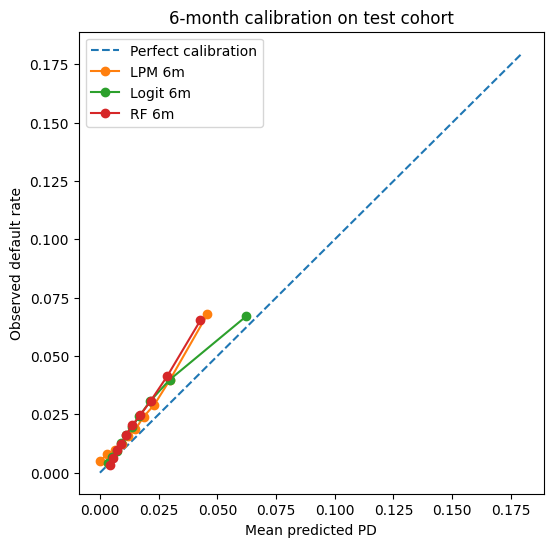

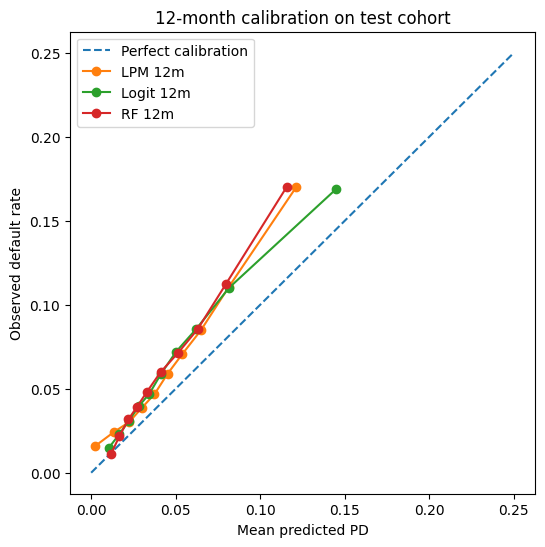

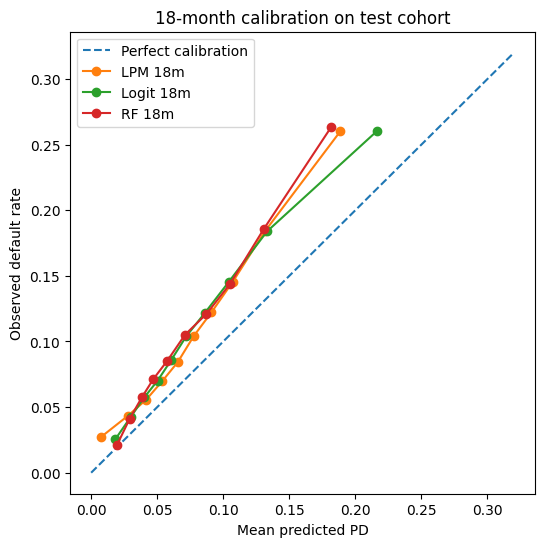

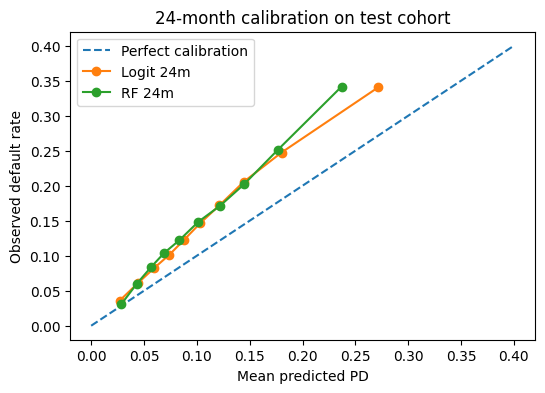

In [70]:

# 6m calibration: LPM vs Logit vs RF
prob_true_lpm_6, prob_pred_lpm_6 = calibration_curve(freq6["y_test"], freq6["test_pred_lpm"], n_bins=10, strategy="quantile")
prob_true_logit_6, prob_pred_logit_6 = calibration_curve(freq6["y_test"], freq6["test_pred_logit"], n_bins=10, strategy="quantile")
prob_true_rf_6, prob_pred_rf_6 = calibration_curve(freq6["y_test"], freq6["test_pred_rf"], n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot([0, 0.18], [0, 0.18], linestyle="--", label="Perfect calibration")
plt.plot(prob_pred_lpm_6, prob_true_lpm_6, marker="o", label="LPM 6m")
plt.plot(prob_pred_logit_6, prob_true_logit_6, marker="o", label="Logit 6m")
plt.plot(prob_pred_rf_6, prob_true_rf_6, marker="o", label="RF 6m")
plt.xlabel("Mean predicted PD")
plt.ylabel("Observed default rate")
plt.title("6-month calibration on test cohort")
plt.legend()
plt.show()

# 12m calibration: LPM vs Logit vs RF
prob_true_lpm_12, prob_pred_lpm_12 = calibration_curve(freq12["y_test"], freq12["test_pred_lpm"], n_bins=10, strategy="quantile")
prob_true_logit_12, prob_pred_logit_12 = calibration_curve(freq12["y_test"], freq12["test_pred_logit"], n_bins=10, strategy="quantile")
prob_true_rf_12, prob_pred_rf_12 = calibration_curve(freq12["y_test"], freq12["test_pred_rf"], n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot([0, 0.25], [0, 0.25], linestyle="--", label="Perfect calibration")
plt.plot(prob_pred_lpm_12, prob_true_lpm_12, marker="o", label="LPM 12m")
plt.plot(prob_pred_logit_12, prob_true_logit_12, marker="o", label="Logit 12m")
plt.plot(prob_pred_rf_12, prob_true_rf_12, marker="o", label="RF 12m")
plt.xlabel("Mean predicted PD")
plt.ylabel("Observed default rate")
plt.title("12-month calibration on test cohort")
plt.legend()
plt.show()

# 18m calibration: LPM vs Logit vs RF
prob_true_lpm_18, prob_pred_lpm_18 = calibration_curve(freq18["y_test"], freq18["test_pred_lpm"], n_bins=10, strategy="quantile")
prob_true_logit_18, prob_pred_logit_18 = calibration_curve(freq18["y_test"], freq18["test_pred_logit"], n_bins=10, strategy="quantile")
prob_true_rf_18, prob_pred_rf_18 = calibration_curve(freq18["y_test"], freq18["test_pred_rf"], n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot([0, 0.32], [0, 0.32], linestyle="--", label="Perfect calibration")
plt.plot(prob_pred_lpm_18, prob_true_lpm_18, marker="o", label="LPM 18m")
plt.plot(prob_pred_logit_18, prob_true_logit_18, marker="o", label="Logit 18m")
plt.plot(prob_pred_rf_18, prob_true_rf_18, marker="o", label="RF 18m")
plt.xlabel("Mean predicted PD")
plt.ylabel("Observed default rate")
plt.title("18-month calibration on test cohort")
plt.legend()
plt.show()

# 24m calibration: compare all fixed-horizon models against Cox later
prob_true_logit_24, prob_pred_logit_24 = calibration_curve(freq24["y_test"], freq24["test_pred_logit"], n_bins=10, strategy="quantile")
prob_true_rf_24, prob_pred_rf_24 = calibration_curve(freq24["y_test"], freq24["test_pred_rf"], n_bins=10, strategy="quantile")
plt.figure(figsize=(6, 4))
plt.plot([0, 0.40], [0, 0.40], linestyle="--", label="Perfect calibration")
plt.plot(prob_pred_logit_24, prob_true_logit_24, marker="o", label="Logit 24m")
plt.plot(prob_pred_rf_24, prob_true_rf_24, marker="o", label="RF 24m")
plt.xlabel("Mean predicted PD")
plt.ylabel("Observed default rate")
plt.title("24-month calibration on test cohort")
plt.legend()
plt.show()

### 7.2 Random forest feature importance

The forest is a benchmark rather than the main PD model, so this view helps check whether it is picking up the same broad credit signals as the Cox fit.

,feature,importance
0,num__int_rate,0.226227
17,cat__grade_A,0.108956
3,num__annual_inc,0.072179
14,num__fico_avg,0.068621
18,cat__grade_B,0.054399
4,num__dti,0.051618
21,cat__grade_E,0.035923
15,num__credit_history_years,0.031596
2,num__installment,0.031514
9,num__revol_bal,0.029158


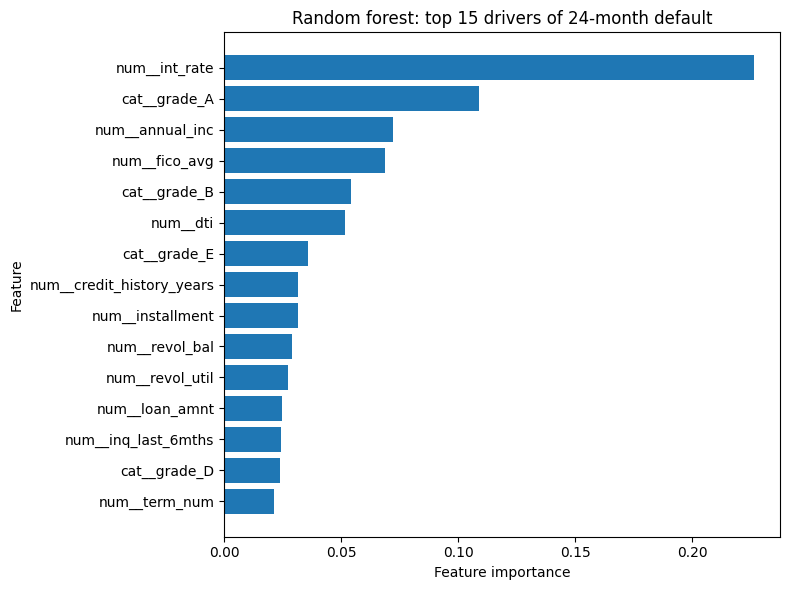

In [71]:
rf_feature_names_24 = freq24["rf_raw"].named_steps["prep"].get_feature_names_out()
rf_feature_importance_24 = pd.DataFrame({
    "feature": rf_feature_names_24,
    "importance": freq24["rf_raw"].named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)

display(rf_feature_importance_24.head(20))

plt.figure(figsize=(8, 6))
top_rf_importance = rf_feature_importance_24.head(15).sort_values("importance")
plt.barh(top_rf_importance["feature"], top_rf_importance["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random forest: top 15 drivers of 24-month default")
plt.tight_layout()
plt.show()

## 8. Cox PH as the time-to-default extension


In [72]:

cox_numeric = model_numeric.copy()
cox_categorical = model_categorical.copy()

def prepare_cox_design(train_df, eval_df):
    train_term = train_df[["id", "duration_months", "default_event"] + cox_numeric + cox_categorical].copy()
    eval_term = eval_df[["id", "duration_months", "default_event"] + cox_numeric + cox_categorical].copy()

    for frame in [train_term, eval_term]:
        for c in cox_numeric + ["duration_months", "default_event"]:
            frame[c] = pd.to_numeric(frame[c], errors="coerce")
        for c in cox_categorical:
            frame[c] = frame[c].astype("string").fillna("Missing")

    train_term = train_term.dropna(subset=["duration_months", "default_event"]).copy()
    eval_term = eval_term.dropna(subset=["duration_months", "default_event"]).copy()

    train_medians = train_term[cox_numeric].median(numeric_only=True)
    train_term[cox_numeric] = train_term[cox_numeric].fillna(train_medians)
    eval_term[cox_numeric] = eval_term[cox_numeric].fillna(train_medians)

    train_dm = pd.get_dummies(train_term, columns=cox_categorical, drop_first=True)
    eval_dm = pd.get_dummies(eval_term, columns=cox_categorical, drop_first=True)

    feature_cols = [c for c in train_dm.columns if c not in ["id", "duration_months", "default_event"]]

    for c in feature_cols:
        if c not in eval_dm.columns:
            eval_dm[c] = 0

    extra_eval = [c for c in eval_dm.columns if c not in ["id", "duration_months", "default_event"] + feature_cols]
    if extra_eval:
        eval_dm = eval_dm.drop(columns=extra_eval)

    train_dm = train_dm[["id", "duration_months", "default_event"] + feature_cols].copy()
    eval_dm = eval_dm[["id", "duration_months", "default_event"] + feature_cols].copy()

    for frame in [train_dm, eval_dm]:
        bool_cols = frame.select_dtypes(include=["bool"]).columns
        if len(bool_cols) > 0:
            frame[bool_cols] = frame[bool_cols].astype(int)
        frame[feature_cols] = frame[feature_cols].astype(float)
        frame["duration_months"] = frame["duration_months"].astype(float)
        frame["default_event"] = frame["default_event"].astype(int)

    nunique = train_dm[feature_cols].nunique(dropna=False)
    constant_cols = nunique[nunique <= 1].index.tolist()
    if constant_cols:
        feature_cols = [c for c in feature_cols if c not in constant_cols]
        train_dm = train_dm[["id", "duration_months", "default_event"] + feature_cols].copy()
        eval_dm = eval_dm[["id", "duration_months", "default_event"] + feature_cols].copy()

    return train_dm, eval_dm, feature_cols

cox_train, cox_valid, cox_features = prepare_cox_design(train_loans, valid_loans)
_, cox_test, _ = prepare_cox_design(train_loans, test_loans)

cph = CoxPHFitter(penalizer=0.1)
cph.fit(
    cox_train.drop(columns=["id"]),
    duration_col="duration_months",
    event_col="default_event",
    show_progress=False,
)

valid_risk = cph.predict_partial_hazard(cox_valid[cox_features]).values.ravel()
test_risk = cph.predict_partial_hazard(cox_test[cox_features]).values.ravel()

cox_c_valid = concordance_index(
    cox_valid["duration_months"],
    -valid_risk,
    cox_valid["default_event"],
)
cox_c_test = concordance_index(
    cox_test["duration_months"],
    -test_risk,
    cox_test["default_event"],
)

cox_summary = pd.DataFrame([{
    "model": "Cox_PH_time_to_default",
    "valid_c_index": cox_c_valid,
    "test_c_index": cox_c_test,
    "n_train": len(cox_train),
    "n_valid": len(cox_valid),
    "n_test": len(cox_test),
}])

display(cox_summary)

,model,valid_c_index,test_c_index,n_train,n_valid,n_test
0,Cox_PH_time_to_default,0.685673,0.693352,466345,421095,1373228


### 8.1 The strongest Cox hazard ratios

In [73]:

cox_coef_view = cph.summary[["coef", "exp(coef)", "se(coef)", "z", "p"]].sort_values("exp(coef)", ascending=False)
display(cox_coef_view.head(20))

,coef,exp(coef),se(coef),z,p
covariate,,,,,
grade_G,0.327748,1.387840,0.027008,12.135345,6.862024e-34
purpose_small_business,0.289166,1.335313,0.021408,13.507466,1.413014e-41
grade_F,0.266647,1.305580,0.015510,17.191774,3.060243e-66
grade_E,0.245254,1.277946,0.010704,22.912775,3.465535e-116
grade_D,0.184431,1.202534,0.008228,22.415839,2.757953e-111
emp_length_Missing,0.176933,1.193551,0.013567,13.041089,7.142965e-39
purpose_educational,0.174224,1.190323,0.090512,1.924884,5.424384e-02
purpose_renewable_energy,0.129382,1.138124,0.101379,1.276221,2.018775e-01
home_ownership_OTHER,0.126533,1.134887,0.136350,0.927997,3.534089e-01


### 8.2 Supported-horizon Cox curve check

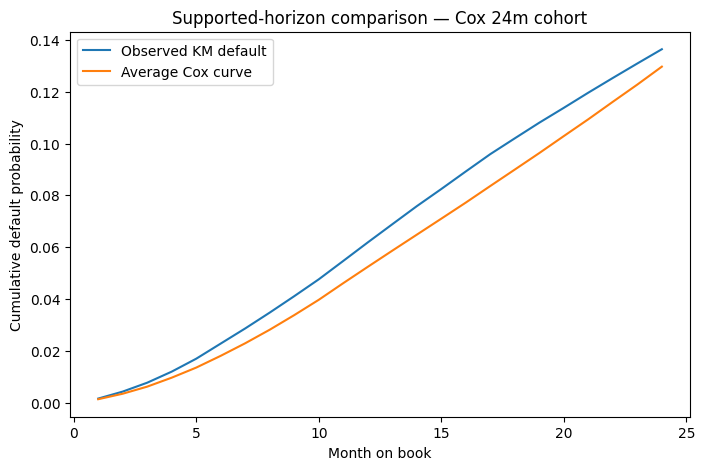

In [74]:

def km_curve(loans, max_horizon=None):
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=loans["duration_months"],
        event_observed=loans["default_event"],
    )
    surv = kmf.survival_function_.reset_index()
    surv.columns = ["month_on_book", "survival"]
    surv["month_on_book"] = surv["month_on_book"].astype(float).round().astype(int)
    surv["cum_default_km"] = 1 - surv["survival"]
    if max_horizon is not None:
        surv = surv[surv["month_on_book"] <= max_horizon].copy()
    return surv

km_test = km_curve(test_loans, max_horizon=LONG_HORIZON)

surv_pred_test = cph.predict_survival_function(cox_test[cox_features])
avg_surv = surv_pred_test.mean(axis=1).reset_index()
avg_surv.columns = ["month_on_book", "survival_cox_avg"]
avg_surv["month_on_book"] = avg_surv["month_on_book"].astype(float).round().astype(int)
avg_surv = avg_surv.groupby("month_on_book", as_index=False)["survival_cox_avg"].last()
avg_surv["cum_default_cox_avg"] = 1 - avg_surv["survival_cox_avg"]

compare_curve = km_test.merge(
    avg_surv[["month_on_book", "cum_default_cox_avg"]],
    on="month_on_book",
    how="inner",
)

plt.figure(figsize=(8, 5))
plt.plot(compare_curve["month_on_book"], compare_curve["cum_default_km"], label="Observed KM default")
plt.plot(compare_curve["month_on_book"], compare_curve["cum_default_cox_avg"], label="Average Cox curve")
plt.xlabel("Month on book")
plt.ylabel("Cumulative default probability")
plt.title(f"Supported-horizon comparison — Cox {LONG_HORIZON}m cohort")
plt.legend()
plt.show()

## 9. Convert Cox into a simple 24-month PD and compare it with 24-month logit


In [80]:

# 18m PD from Cox on the validation/test sets
cox_valid_18 = cph.predict_survival_function(cox_valid[cox_features], times=[EIGHTEEN_HORIZON]).T
cox_valid_18.columns = ["survival_18m"]
cox_valid_18["pd_18m_cox"] = 1 - cox_valid_18["survival_18m"]
cox_valid_18 = cox_valid_18.reset_index(drop=True)
cox_valid_18["id"] = cox_valid["id"].values

cox_test_18 = cph.predict_survival_function(cox_test[cox_features], times=[EIGHTEEN_HORIZON]).T
cox_test_18.columns = ["survival_18m"]
cox_test_18["pd_18m_cox"] = 1 - cox_test_18["survival_18m"]
cox_test_18 = cox_test_18.reset_index(drop=True)
cox_test_18["id"] = cox_test["id"].values

valid18_compare = valid_18[["id", f"default_within_{EIGHTEEN_HORIZON}m"]].merge(
    cox_valid_18[["id", "pd_18m_cox"]],
    on="id",
    how="inner",
)
test18_compare = test_18[["id", f"default_within_{EIGHTEEN_HORIZON}m"]].merge(
    cox_test_18[["id", "pd_18m_cox"]],
    on="id",
    how="inner",
)

valid18_compare["pd_18m_logit"] = freq18["valid_pred_logit"]
test18_compare["pd_18m_logit"] = freq18["test_pred_logit"]
valid18_compare["pd_18m_rf"] = freq18["valid_pred_rf"]
test18_compare["pd_18m_rf"] = freq18["test_pred_rf"]

y_valid_18 = valid18_compare[f"default_within_{EIGHTEEN_HORIZON}m"]
y_test_18 = test18_compare[f"default_within_{EIGHTEEN_HORIZON}m"]

longterm_results = pd.DataFrame([
    {
        "model": "Logit_18m",
        "valid_roc_auc": roc_auc_score(y_valid_18, valid18_compare["pd_18m_logit"]),
        "valid_pr_auc": average_precision_score(y_valid_18, valid18_compare["pd_18m_logit"]),
        "valid_brier": brier_score_loss(y_valid_18, valid18_compare["pd_18m_logit"]),
        "test_roc_auc": roc_auc_score(y_test_18, test18_compare["pd_18m_logit"]),
        "test_pr_auc": average_precision_score(y_test_18, test18_compare["pd_18m_logit"]),
        "test_brier": brier_score_loss(y_test_18, test18_compare["pd_18m_logit"]),
    },
    {
        "model": "Cox_implied_PD_18m",
        "valid_roc_auc": roc_auc_score(y_valid_18, valid18_compare["pd_18m_cox"]),
        "valid_pr_auc": average_precision_score(y_valid_18, valid18_compare["pd_18m_cox"]),
        "valid_brier": brier_score_loss(y_valid_18, valid18_compare["pd_18m_cox"]),
        "test_roc_auc": roc_auc_score(y_test_18, test18_compare["pd_18m_cox"]),
        "test_pr_auc": average_precision_score(y_test_18, test18_compare["pd_18m_cox"]),
        "test_brier": brier_score_loss(y_test_18, test18_compare["pd_18m_cox"]),
    },
    {
        "model": "RF_18m",
        "valid_roc_auc": roc_auc_score(y_valid_18, valid18_compare["pd_18m_rf"]),
        "valid_pr_auc": average_precision_score(y_valid_18, valid18_compare["pd_18m_rf"]),
        "valid_brier": brier_score_loss(y_valid_18, valid18_compare["pd_18m_rf"]),
        "test_roc_auc": roc_auc_score(y_test_18, test18_compare["pd_18m_rf"]),
        "test_pr_auc": average_precision_score(y_test_18, test18_compare["pd_18m_rf"]),
        "test_brier": brier_score_loss(y_test_18, test18_compare["pd_18m_rf"]),
    },
    {
        "model": "Logit_24m",
        "valid_roc_auc": roc_auc_score(y_valid_24, valid24_compare["pd_24m_logit"]),
        "valid_pr_auc": average_precision_score(y_valid_24, valid24_compare["pd_24m_logit"]),
        "valid_brier": brier_score_loss(y_valid_24, valid24_compare["pd_24m_logit"]),
        "test_roc_auc": roc_auc_score(y_test_24, test24_compare["pd_24m_logit"]),
        "test_pr_auc": average_precision_score(y_test_24, test24_compare["pd_24m_logit"]),
        "test_brier": brier_score_loss(y_test_24, test24_compare["pd_24m_logit"]),
    },
    {
        "model": "Cox_implied_PD_24m",
        "valid_roc_auc": roc_auc_score(y_valid_24, valid24_compare["pd_24m_cox"]),
        "valid_pr_auc": average_precision_score(y_valid_24, valid24_compare["pd_24m_cox"]),
        "valid_brier": brier_score_loss(y_valid_24, valid24_compare["pd_24m_cox"]),
        "test_roc_auc": roc_auc_score(y_test_24, test24_compare["pd_24m_cox"]),
        "test_pr_auc": average_precision_score(y_test_24, test24_compare["pd_24m_cox"]),
        "test_brier": brier_score_loss(y_test_24, test24_compare["pd_24m_cox"]),
    },
    {
        "model": "RF_24m",
        "valid_roc_auc": roc_auc_score(y_valid_24, valid24_compare["pd_24m_rf"]),
        "valid_pr_auc": average_precision_score(y_valid_24, valid24_compare["pd_24m_rf"]),
        "valid_brier": brier_score_loss(y_valid_24, valid24_compare["pd_24m_rf"]),
        "test_roc_auc": roc_auc_score(y_test_24, test24_compare["pd_24m_rf"]),
        "test_pr_auc": average_precision_score(y_test_24, test24_compare["pd_24m_rf"]),
        "test_brier": brier_score_loss(y_test_24, test24_compare["pd_24m_rf"]),
    },
])

display(longterm_results)

,model,valid_roc_auc,valid_pr_auc,valid_brier,test_roc_auc,test_pr_auc,test_brier
0,Logit_18m,0.702083,0.202738,0.086927,0.693077,0.212167,0.094083
1,Cox_implied_PD_18m,0.703615,0.205363,0.086925,0.695077,0.215543,0.093893
2,RF_18m,0.706026,0.204582,0.086770,0.697210,0.216123,0.094172
3,Logit_24m,0.697765,0.254254,0.109875,0.693415,0.280805,0.122609
4,Cox_implied_PD_24m,0.699143,0.257015,0.109599,0.695005,0.283241,0.121670
5,RF_24m,0.700539,0.255529,0.109768,0.695883,0.282027,0.123107


### 9.1 Calibration: 24m logit vs 24m Cox

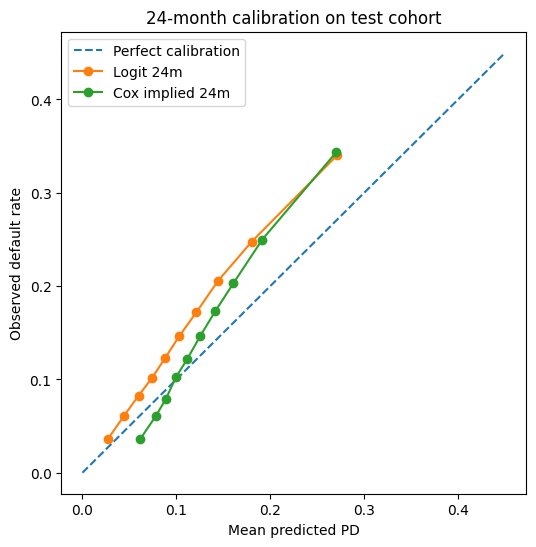

In [76]:

prob_true_logit_24, prob_pred_logit_24 = calibration_curve(
    y_test_24, test24_compare["pd_24m_logit"], n_bins=10, strategy="quantile"
)
prob_true_cox_24, prob_pred_cox_24 = calibration_curve(
    y_test_24, test24_compare["pd_24m_cox"], n_bins=10, strategy="quantile"
)

plt.figure(figsize=(6, 6))
plt.plot([0, 0.45], [0, 0.45], linestyle="--", label="Perfect calibration")
plt.plot(prob_pred_logit_24, prob_true_logit_24, marker="o", label="Logit 24m")
plt.plot(prob_pred_cox_24, prob_true_cox_24, marker="o", label="Cox implied 24m")
plt.xlabel("Mean predicted PD")
plt.ylabel("Observed default rate")
plt.title("24-month calibration on test cohort")
plt.legend()
plt.show()

## 10. Choose the simplest long-term model

In [81]:

lt = longterm_results.set_index("model")
rf_margin = 0.001

rf_brier = lt.loc["RF_24m", "valid_brier"]
cox_brier = lt.loc["Cox_implied_PD_24m", "valid_brier"]
logit_brier = lt.loc["Logit_24m", "valid_brier"]

rf_is_best = rf_brier <= min(cox_brier, logit_brier) - rf_margin

if rf_is_best:
    chosen_longterm_model = "RF_24m"
elif cox_brier <= logit_brier - rf_margin:
    chosen_longterm_model = "Cox_implied_PD_24m"
else:
    chosen_longterm_model = "Logit_24m"

selection_table = longterm_results.copy()
selection_table["chosen_for_simple_longterm"] = selection_table["model"].eq(chosen_longterm_model)
display(selection_table)

print("Chosen simple long-term PD model:", chosen_longterm_model)

,model,valid_roc_auc,valid_pr_auc,valid_brier,test_roc_auc,test_pr_auc,test_brier,chosen_for_simple_longterm
0,Logit_18m,0.702083,0.202738,0.086927,0.693077,0.212167,0.094083,False
1,Cox_implied_PD_18m,0.703615,0.205363,0.086925,0.695077,0.215543,0.093893,False
2,RF_18m,0.706026,0.204582,0.086770,0.697210,0.216123,0.094172,False
3,Logit_24m,0.697765,0.254254,0.109875,0.693415,0.280805,0.122609,True
4,Cox_implied_PD_24m,0.699143,0.257015,0.109599,0.695005,0.283241,0.121670,False
5,RF_24m,0.700539,0.255529,0.109768,0.695883,0.282027,0.123107,False


Chosen simple long-term PD model: Logit_24m


## 11. Refit final production-style models on train + validation


In [ ]:

# Combine train+valid for final fitting
tv_loans = pd.concat([train_loans, valid_loans], ignore_index=True)
tv_6 = pd.concat([train_6, valid_6], ignore_index=True)
tv_12 = pd.concat([train_12, valid_12], ignore_index=True)
tv_18 = pd.concat([train_18, valid_18], ignore_index=True)
tv_24 = pd.concat([train_24, valid_24], ignore_index=True)

# Final 6m logit
X_tv_6 = tv_6[model_numeric + model_categorical]
y_tv_6 = tv_6[f"default_within_{SIX_HORIZON}m"]

final_logit_6 = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000, C=0.5, random_state=RANDOM_STATE)),
])
final_logit_6.fit(X_tv_6, y_tv_6)

# Final 18m logit
X_tv_18 = tv_18[model_numeric + model_categorical]
y_tv_18 = tv_18[f"default_within_{EIGHTEEN_HORIZON}m"]

final_logit_18 = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000, C=0.5, random_state=RANDOM_STATE)),
])
final_logit_18.fit(X_tv_18, y_tv_18)

# Final 12m logit
X_tv_12 = tv_12[model_numeric + model_categorical]
y_tv_12 = tv_12[f"default_within_{SHORT_HORIZON}m"]

final_logit_12 = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000, C=0.5, random_state=RANDOM_STATE)),
])
final_logit_12.fit(X_tv_12, y_tv_12)

# Final 24m logit
X_tv_24 = tv_24[model_numeric + model_categorical]
y_tv_24 = tv_24[f"default_within_{LONG_HORIZON}m"]

final_logit_24 = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000, C=0.5, random_state=RANDOM_STATE)),
])
final_logit_24.fit(X_tv_24, y_tv_24)

# Final RF models for 6m and 18m
final_rf_raw_6 = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=50,
        max_features="sqrt",
        class_weight="balanced_subsample",
        max_samples=0.7,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
final_rf_6 = CalibratedClassifierCV(estimator=final_rf_raw_6, method="sigmoid", cv=3)
final_rf_6.fit(X_tv_6, y_tv_6)

final_rf_raw_18 = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=50,
        max_features="sqrt",
        class_weight="balanced_subsample",
        max_samples=0.7,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
final_rf_18 = CalibratedClassifierCV(estimator=final_rf_raw_18, method="sigmoid", cv=3)
final_rf_18.fit(X_tv_18, y_tv_18)

# Final RF models
final_rf_raw_12 = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=50,
        max_features="sqrt",
        class_weight="balanced_subsample",
        max_samples=0.7,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
final_rf_12 = CalibratedClassifierCV(estimator=final_rf_raw_12, method="sigmoid", cv=3)
final_rf_12.fit(X_tv_12, y_tv_12)

final_rf_raw_24 = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=50,
        max_features="sqrt",
        class_weight="balanced_subsample",
        max_samples=0.7,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
final_rf_24 = CalibratedClassifierCV(estimator=final_rf_raw_24, method="sigmoid", cv=3)
final_rf_24.fit(X_tv_24, y_tv_24)

# Final Cox
final_cox_train, final_cox_all, final_cox_features = prepare_cox_design(tv_loans, df_model)
final_cph = CoxPHFitter(penalizer=0.1)
final_cph.fit(
    final_cox_train.drop(columns=["id"]),
    duration_col="duration_months",
    event_col="default_event",
    show_progress=False,
)

## 12. Score the whole modeled portfolio

In [ ]:

pd_output = df_model[[
    "id", "issue_d", "loan_status", "grade", "int_rate", "loan_amnt",
    "annual_inc", "dti", "fico_avg", "term_num"
 ]].copy()

X_all = df_model[model_numeric + model_categorical]
pd_output["pd_6m_logit"] = final_logit_6.predict_proba(X_all)[:, 1]
pd_output["pd_12m_logit"] = final_logit_12.predict_proba(X_all)[:, 1]
pd_output["pd_18m_logit"] = final_logit_18.predict_proba(X_all)[:, 1]
pd_output["pd_24m_logit"] = final_logit_24.predict_proba(X_all)[:, 1]
pd_output["pd_6m_rf"] = final_rf_6.predict_proba(X_all)[:, 1]
pd_output["pd_12m_rf"] = final_rf_12.predict_proba(X_all)[:, 1]
pd_output["pd_18m_rf"] = final_rf_18.predict_proba(X_all)[:, 1]
pd_output["pd_24m_rf"] = final_rf_24.predict_proba(X_all)[:, 1]

cox_all_6 = final_cph.predict_survival_function(final_cox_all[final_cox_features], times=[SIX_HORIZON]).T
cox_all_6.columns = ["survival_6m"]
cox_all_6["pd_6m_cox"] = 1 - cox_all_6["survival_6m"]
cox_all_6 = cox_all_6.reset_index(drop=True)
cox_all_6["id"] = final_cox_all["id"].values

cox_all_18 = final_cph.predict_survival_function(final_cox_all[final_cox_features], times=[EIGHTEEN_HORIZON]).T
cox_all_18.columns = ["survival_18m"]
cox_all_18["pd_18m_cox"] = 1 - cox_all_18["survival_18m"]
cox_all_18 = cox_all_18.reset_index(drop=True)
cox_all_18["id"] = final_cox_all["id"].values

cox_all_24 = final_cph.predict_survival_function(final_cox_all[final_cox_features], times=[LONG_HORIZON]).T
cox_all_24.columns = ["survival_24m"]
cox_all_24["pd_24m_cox"] = 1 - cox_all_24["survival_24m"]
cox_all_24 = cox_all_24.reset_index(drop=True)
cox_all_24["id"] = final_cox_all["id"].values

pd_output = pd_output.merge(cox_all_6[["id", "pd_6m_cox"]], on="id", how="left")
pd_output = pd_output.merge(cox_all_18[["id", "pd_18m_cox"]], on="id", how="left")
pd_output = pd_output.merge(cox_all_24[["id", "pd_24m_cox"]], on="id", how="left")

if chosen_longterm_model == "Cox_implied_PD_24m":
    pd_output["pd_24m_chosen"] = pd_output["pd_24m_cox"]
elif chosen_longterm_model == "RF_24m":
    pd_output["pd_24m_chosen"] = pd_output["pd_24m_rf"]
else:
    pd_output["pd_24m_chosen"] = pd_output["pd_24m_logit"]

pd_output["chosen_longterm_model"] = chosen_longterm_model

display(pd_output.head())

pd_output.to_csv(OUTPUT_DIR / "pd_predictions_for_teammates.csv", index=False)
frequency_results.to_csv(OUTPUT_DIR / "frequency_model_metrics.csv", index=False)
longterm_results.to_csv(OUTPUT_DIR / "longterm_model_comparison.csv", index=False)
cox_summary.to_csv(OUTPUT_DIR / "cox_time_to_default_summary.csv", index=False)

print("Saved:")
print("-", OUTPUT_DIR / "pd_predictions_for_teammates.csv")
print("-", OUTPUT_DIR / "frequency_model_metrics.csv")
print("-", OUTPUT_DIR / "longterm_model_comparison.csv")
print("-", OUTPUT_DIR / "cox_time_to_default_summary.csv")

,id,issue_d,loan_status,grade,int_rate,loan_amnt,annual_inc,dti,fico_avg,term_num,...,pd_24m_logit,pd_6m_rf,pd_12m_rf,pd_18m_rf,pd_24m_rf,pd_6m_cox,pd_18m_cox,pd_24m_cox,pd_24m_chosen,chosen_longterm_model
0,68407277,2015-12-01,Fully Paid,C,13.99,3600.0,55000.0,5.91,677.0,36.0,...,0.102377,0.019530,0.047472,0.075663,0.099604,0.017292,0.091125,0.130483,0.102377,Logit_24m
1,68355089,2015-12-01,Fully Paid,C,11.99,24700.0,65000.0,16.06,717.0,36.0,...,0.190163,0.017766,0.053313,0.095833,0.124430,0.023511,0.122188,0.173624,0.190163,Logit_24m
2,68341763,2015-12-01,Fully Paid,B,10.78,20000.0,63000.0,10.78,697.0,60.0,...,0.054399,0.007798,0.020744,0.036196,0.053914,0.010489,0.056122,0.081046,0.054399,Logit_24m
3,66310712,2015-12-01,Current,C,14.85,35000.0,110000.0,17.06,787.0,60.0,...,0.091440,0.013938,0.046853,0.069567,0.104345,0.016495,0.087084,0.124820,0.091440,Logit_24m
4,68476807,2015-12-01,Fully Paid,F,22.45,10400.0,104433.0,25.37,697.0,60.0,...,0.235424,0.034827,0.104308,0.138697,0.221449,0.034882,0.176742,0.247683,0.235424,Logit_24m


Saved:
- data/simplification_PD/pd_predictions_for_teammates.csv
- data/simplification_PD/frequency_model_metrics.csv
- data/simplification_PD/longterm_model_comparison.csv
- data/simplification_PD/cox_time_to_default_summary.csv
